In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [ ]:
df = pd.read_csv("/content/Online Retail.csv", encoding='ISO-8859-1')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   541909 non-null  int64  
 7   Country      541909 non-null  object 
dtypes: float64(1), int64(2), object(5)
memory usage: 33.1+ MB


In [ ]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,541909.000000
mean,9.552250,4.611114,15287.518434
std,218.081158,96.759853,1484.746041
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,14367.000000
50%,3.000000,2.080000,15287.000000
75%,10.000000,4.130000,16255.000000
max,80995.000000,38970.000000,18287.000000


In [ ]:
#check for missing values
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0
TotalPrice,0


In [ ]:
#remove cancelled orders
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]

In [ ]:
#convert to date
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [ ]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

In [ ]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


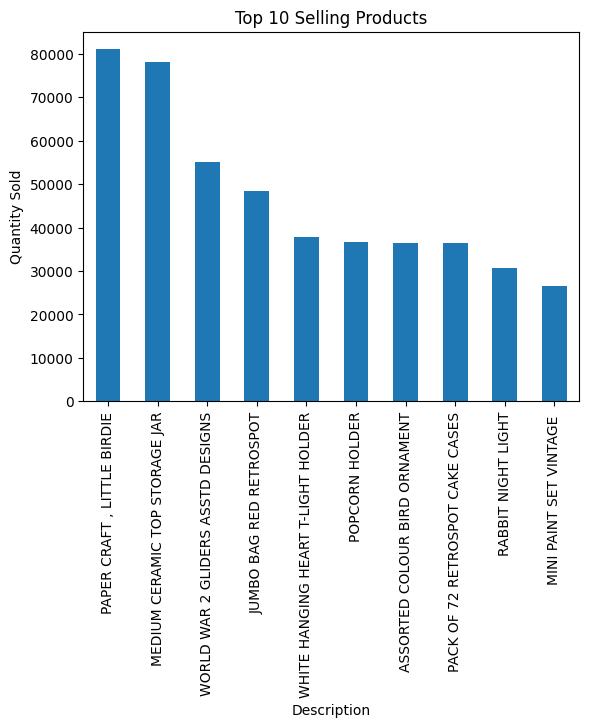

In [ ]:
#EDA
top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

plt.figure()
top_products.plot(kind='bar')
plt.title("Top 10 Selling Products")
plt.ylabel("Quantity Sold")
plt.show()

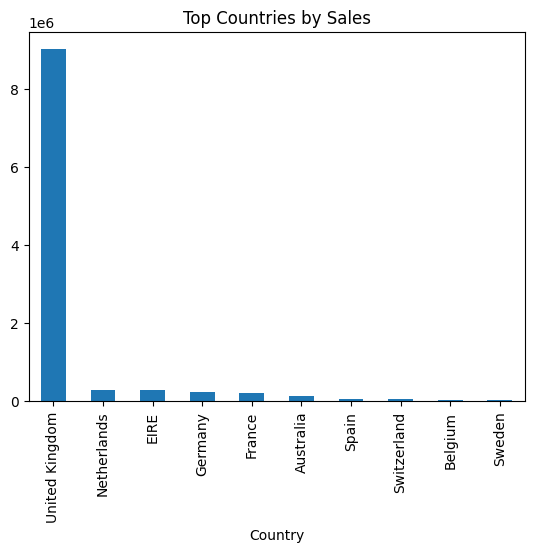

In [ ]:
#Sales by Country
country_sales = df.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(10)

plt.figure()
country_sales.plot(kind='bar')
plt.title("Top Countries by Sales")
plt.show()

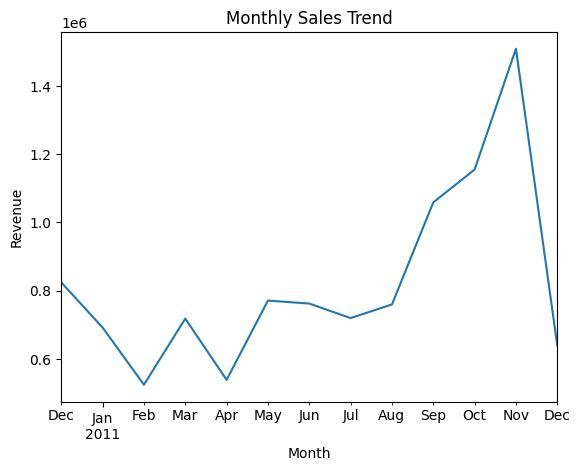

In [ ]:
# Monthly Sales Trend
df['Month'] = df['InvoiceDate'].dt.to_period('M')

monthly_sales = df.groupby('Month')['TotalPrice'].sum()

plt.figure()
monthly_sales.plot()
plt.title("Monthly Sales Trend")
plt.ylabel("Revenue")
plt.show()

RFM ANALYSIS


In [ ]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

In [ ]:
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'count',
    'TotalPrice': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346,326,1,77183.60
12347,2,182,4310.00
12348,75,31,1797.24
12349,19,73,1757.55
12350,310,17,334.40


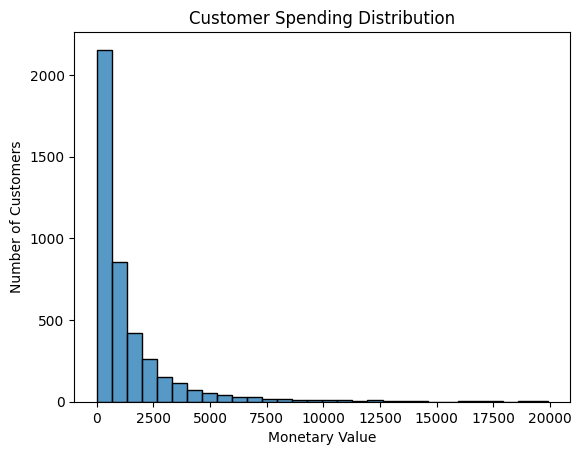

In [ ]:
limit = rfm['Monetary'].quantile(0.99)

plt.figure()
sns.histplot(rfm[rfm['Monetary'] <= limit]['Monetary'], bins=30)

plt.title("Customer Spending Distribution")
plt.xlabel("Monetary Value")
plt.ylabel("Number of Customers")

plt.show()

In [ ]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)

In [ ]:
kmeans = KMeans(n_clusters=4, random_state=42)

rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

rfm.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346,326,1,77183.60,2
12347,2,182,4310.00,0
12348,75,31,1797.24,0
12349,19,73,1757.55,0
12350,310,17,334.40,2


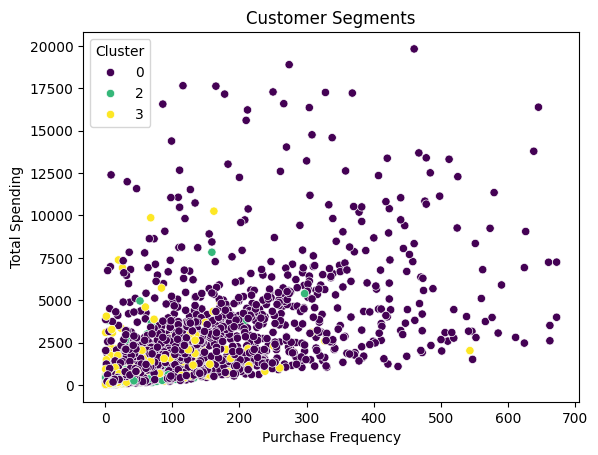

In [ ]:
freq_limit = rfm['Frequency'].quantile(0.99)
mon_limit = rfm['Monetary'].quantile(0.99)

filtered_rfm = rfm[
    (rfm['Frequency'] <= freq_limit) &
    (rfm['Monetary'] <= mon_limit)
]

plt.figure()

sns.scatterplot(
    data=filtered_rfm,
    x='Frequency',
    y='Monetary',
    hue='Cluster',
    palette='viridis'
)

plt.title("Customer Segments")
plt.xlabel("Purchase Frequency")
plt.ylabel("Total Spending")

plt.show()

In [ ]:
cluster_summary = rfm.groupby('Cluster').mean()

cluster_summary

,Recency,Frequency,Monetary
Cluster,,,
0,32.907143,119.758844,2.695797e+03
1,1.000000,132240.000000,1.755763e+06
2,296.336617,23.796388,6.127110e+02
3,157.595178,39.696701,7.768234e+02


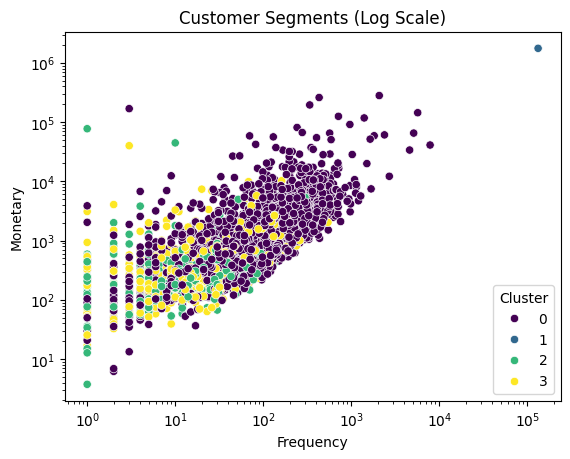

In [ ]:
plt.figure()

sns.scatterplot(
    data=rfm,
    x='Frequency',
    y='Monetary',
    hue='Cluster',
    palette='viridis'
)

plt.xscale('log')
plt.yscale('log')

plt.title("Customer Segments (Log Scale)")
plt.show()

In [ ]:
rfm.to_csv("customer_segments.csv")

In [ ]:
files.download("customer_segments.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>